# 13 - VQC Konvergenz-Analyse: Idealer Simulator vs. Noise Model

Dieses Notebook untersucht das Trainingsverhalten des VQC unter verschiedenen Bedingungen.
Im Fokus steht nicht die finale Accuracy, sondern **wie** der VQC konvergiert:

- Idealer Simulator: schnelle, glatte Konvergenz
- Noise Model: langsamere, unruhigere Konvergenz
- IBM Hardware (auskommentiert): zu teuer für viele Iterationen

**Datensatz:** Iris (3 Klassen, 2 Features, fairer Split - analog zu Notebook 05/09)  
**Variable:** Anzahl Iterationen (maxiter)  
**Metrik:** Cost/Loss pro Iteration (Callback)

## Imports & Setup

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import SPSA
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import SamplerV2 as NoisySampler
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from scipy.optimize import minimize

## Datenvorbereitung (einheitliche Pipeline)

In [2]:
# Iris - Features Index [0, 2] (sepal length + petal length)
iris = load_iris()
X = iris.data[:, [0, 2]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Trainingssamples: {len(X_train)}, Testsamples: {len(X_test)}")

Trainingssamples: 105, Testsamples: 45


## Callback zur Verlaufsspeicherung

In [13]:
def make_callback(cost_history):
    def callback(nfev, x, fx, dx, accept):
        cost_history.append(fx)
    return callback

## Parameter

In [14]:
MAXITER    = 200   # Iterationen für den Vergleich
SHOTS      = 1024
NUM_QUBITS = 2

feature_map = ZZFeatureMap(feature_dimension=NUM_QUBITS, reps=2)
ansatz      = RealAmplitudes(num_qubits=NUM_QUBITS, reps=2)

/tmp/ipykernel_820288/1990626153.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=NUM_QUBITS, reps=2)
/tmp/ipykernel_820288/1990626153.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz      = RealAmplitudes(num_qubits=NUM_QUBITS, reps=2)


## 1. Idealer Simulator

In [15]:
cost_ideal = []

ideal_backend = AerSimulator()
sampler_ideal = StatevectorSampler()

vqc_ideal = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=SPSA(maxiter=MAXITER),  # SPSA
    sampler=sampler_ideal,
    callback=make_callback(cost_ideal)
)

vqc_ideal.fit(X_train, y_train)
acc_ideal = vqc_ideal.score(X_test, y_test)
print(f"Idealer Simulator - Accuracy: {acc_ideal:.4f}, Iterationen: {len(cost_ideal)}")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Idealer Simulator - Accuracy: 0.5111, Iterationen: 200


## 2. Noise Model Simulator

In [23]:
cost_noise = []

# Noise Model (analog zu Notebook 09)
noise_model = NoiseModel()
error_1q = depolarizing_error(0.001, 1)
error_2q = depolarizing_error(0.01, 2)
noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'u1', 'u2', 'u3'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

noisy_backend = AerSimulator(noise_model=noise_model)
pm = generate_preset_pass_manager(optimization_level=1, backend=noisy_backend)
sampler_noisy = NoisySampler.from_backend(noisy_backend)

vqc_noise = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=SPSA(maxiter=MAXITER),
    sampler=sampler_noisy,
    pass_manager=pm,
    callback=make_callback(cost_noise)
)

vqc_noise.fit(X_train, y_train)
acc_noise = vqc_noise.score(X_test, y_test)
print(f"Noise Model - Accuracy: {acc_noise:.4f}, Iterationen: {len(cost_noise)}")

Noise Model - Accuracy: 0.4667, Iterationen: 200


## 3. IBM Hardware (auskommentiert)

> **Hinweis:** Hardware-Jobs sind zu kostspielig für viele Iterationen (10 min QPU/Monat Open Plan).  
> Dieser Block ist für eine spätere Untersuchung vorbereitet - im Text der Studienarbeit ansprechen.

In [ ]:
# cost_hardware = []
#
# from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as HWSampler
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
#
# service = QiskitRuntimeService()
# hw_backend = service.backend('ibm_kingston')
#
# pm = generate_preset_pass_manager(optimization_level=1, backend=hw_backend)
# sampler_hw = HWSampler(hw_backend)
#
# vqc_hw = VQC(
#     feature_map=feature_map,
#     ansatz=ansatz,
#     optimizer=dict(maxiter=MAXITER),
#     sampler=sampler_hw,
#     callback=make_callback(cost_hardware)
# )
#
# vqc_hw.fit(X_train, y_train)
# acc_hw = vqc_hw.score(X_test, y_test)
# print(f"IBM Hardware - Accuracy: {acc_hw:.4f}, Iterationen: {len(cost_hardware)}")

## Visualisierung: Konvergenzverlauf

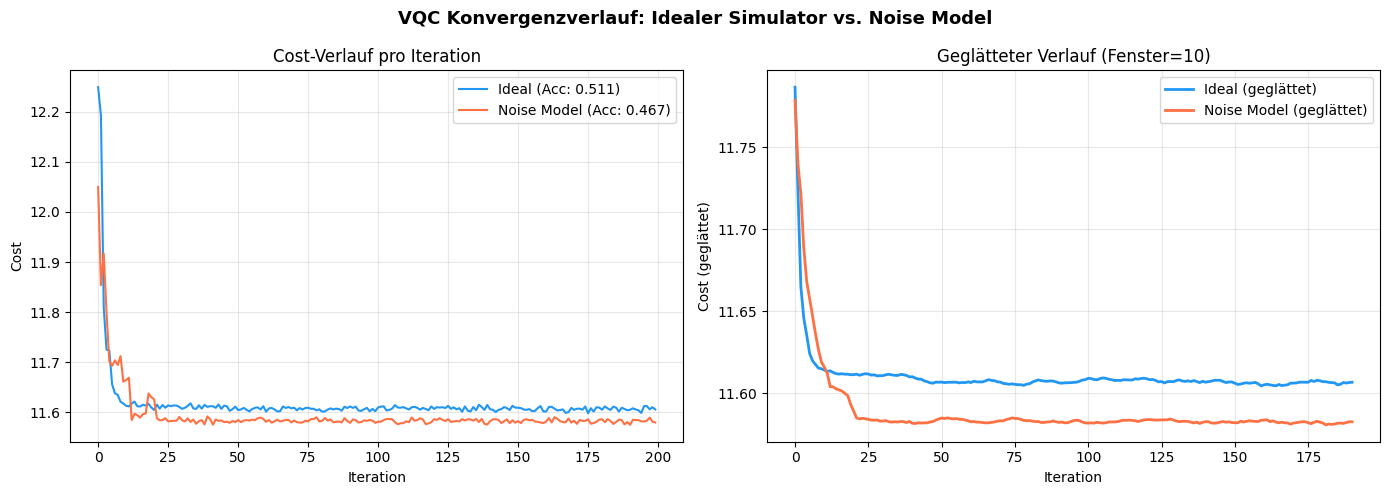

Grafik gespeichert: vqc_konvergenz.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VQC Konvergenzverlauf: Idealer Simulator vs. Noise Model', 
             fontsize=13, fontweight='bold')

# --- Einzelne Verläufe ---
ax1 = axes[0]
ax1.plot(cost_ideal, label=f'Ideal (Acc: {acc_ideal:.3f})', color='#2196F3', linewidth=1.5)
ax1.plot(cost_noise, label=f'Noise Model (Acc: {acc_noise:.3f})', color='#FF7043', linewidth=1.5)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cost')
ax1.set_title('Cost-Verlauf pro Iteration')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Geglättete Verläufe (gleitender Durchschnitt) ---
ax2 = axes[1]
window = 10

def smooth(data, w):
    return np.convolve(data, np.ones(w)/w, mode='valid')

if len(cost_ideal) >= window:
    ax2.plot(smooth(cost_ideal, window), label=f'Ideal (geglättet)', color='#2196F3', linewidth=2)
if len(cost_noise) >= window:
    ax2.plot(smooth(cost_noise, window), label=f'Noise Model (geglättet)', color='#FF7043', linewidth=2)

ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cost (geglättet)')
ax2.set_title(f'Geglätteter Verlauf (Fenster={window})')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('vqc_konvergenz.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik gespeichert: vqc_konvergenz.png")

## Zusammenfassung

In [25]:
print("=" * 50)
print(f"{'Bedingung':<25} {'Accuracy':>10} {'Iterationen':>12}")
print("-" * 50)
print(f"{'Idealer Simulator':<25} {acc_ideal:>10.4f} {len(cost_ideal):>12}")
print(f"{'Noise Model':<25} {acc_noise:>10.4f} {len(cost_noise):>12}")
print("=" * 50)
print()
print("Hinweis: IBM Hardware wurde aufgrund des begrenzten")
print("QPU-Kontingents (10 min/Monat, Open Plan) nicht ausgeführt.")
print("Siehe auskommentierten Block oben.")

Bedingung                   Accuracy  Iterationen
--------------------------------------------------
Idealer Simulator             0.5111          200
Noise Model                   0.4667          200

Hinweis: IBM Hardware wurde aufgrund des begrenzten
QPU-Kontingents (10 min/Monat, Open Plan) nicht ausgeführt.
Siehe auskommentierten Block oben.
